# 2 sums of random variables sampled from fat-tailed distributions

**Fat-Tailed Distribution:**

To generate random numbers from a fat-tailed distribution, we use the **inversion method**. The cumulative distribution function $ F(x) $, associated with the probability density $ p(x) $, is:

$$
F(x) = 1 - \left(\frac{x_0}{x}\right)^\mu, \quad \text{for } x \geq x_0.
$$

From the cumulative distribution function, we derive the inverse formula for $ x $ in terms of a uniform random variable $ u \in [0, 1] $:

$$
x = x_0 (1 - u)^{-1/\mu}, \quad u \in [0, 1].
$$

This relationship allows us to generate random numbers \( x \) that follow the fat-tailed distribution $ p(x) $.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [10]:
# Funzione per generare N numeri casuali dalla distribuzione fat-tailed
def generate_fat_tailed(mu, N, x0=1):
    u = np.random.uniform(0, 1, N)  # Numeri casuali uniformi tra 0 e 1
    return x0 * (1 - u)**(-1 / mu)

def Levi(Z, mu):
   return np.power(Z,-(1+mu))

# Parameters:

setting $x_0 = 1$ means setting a scale for the (dimensinal) variable $x$.

the number of samples for each N is 10000.

In [11]:
# general parameters
x0 = 1  # Valore minimo per la distribuzione
mu_values = [0.3, 0.5, 0.7, 0.9]  # Valori di mu (0 < mu < 1)
N_values = [5, 10, 20 , 40 , 100, 1000, 10000]  # Numeri di variabili casuali
num_samples = 10000  # Numero di set di variabili casuali

# (a) In the following we can see the probability density functions:

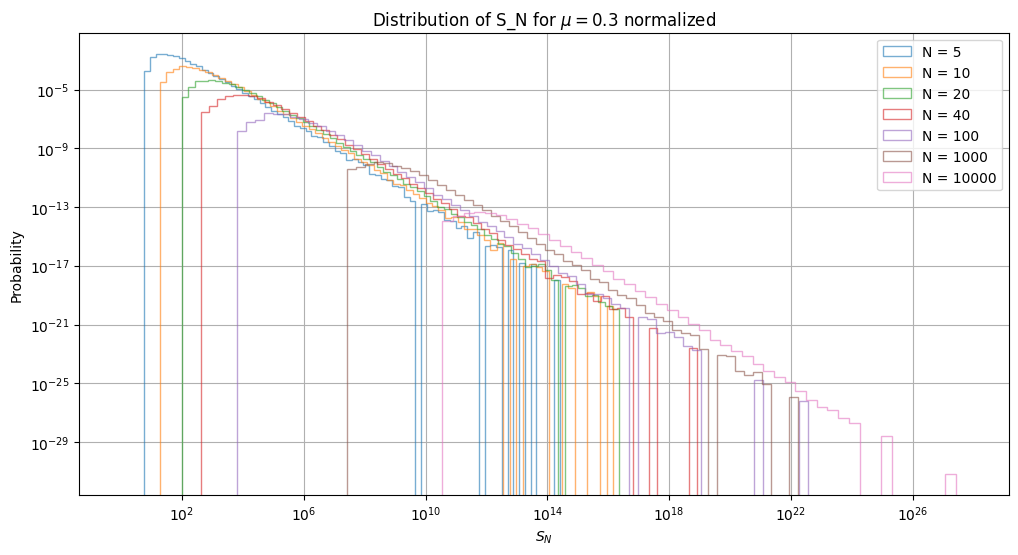

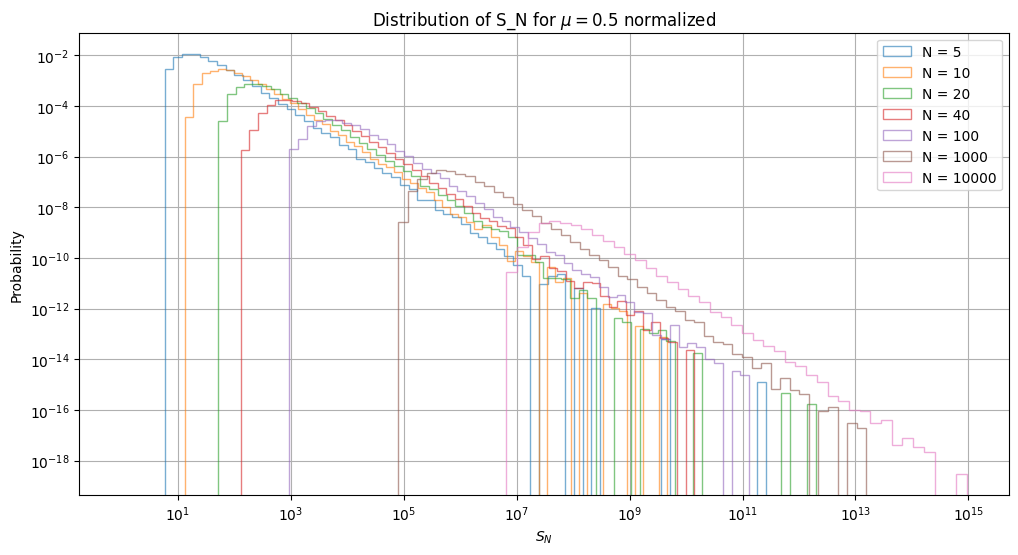

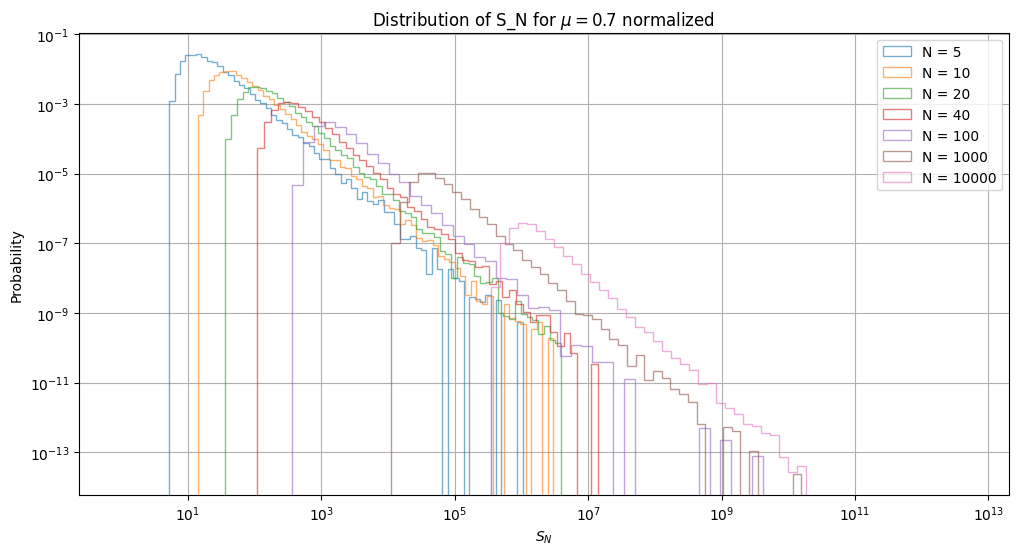

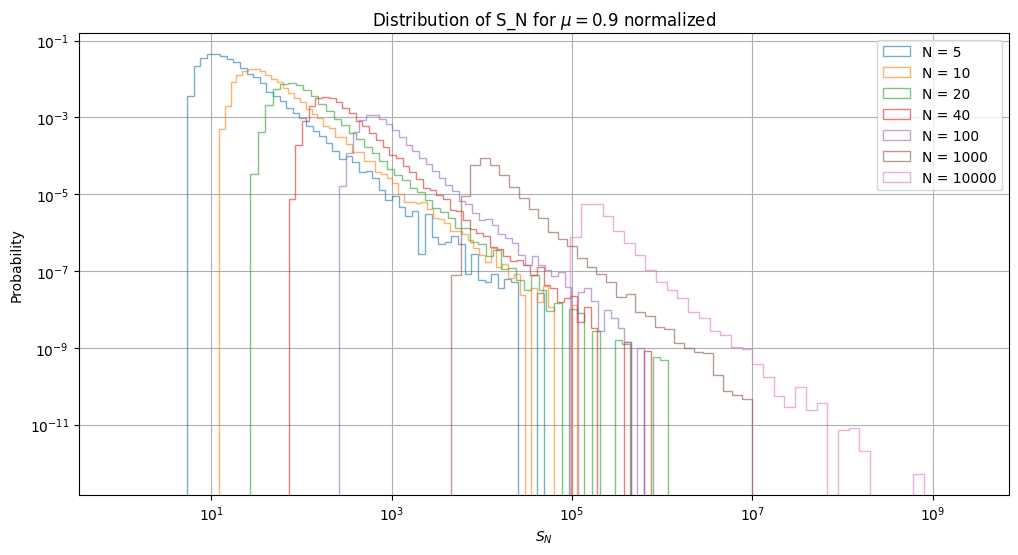

In [12]:
# Loop sui diversi valori di mu e N
for mu in mu_values:
    plt.figure(figsize=(12, 6))
    for N in N_values:
        # Genera molte somme S_N per un dato N
        sums = []
        for _ in range(num_samples):
            xi = generate_fat_tailed(mu, N, x0)
            sums.append(np.sum(xi))
        
        # Istogramma normalizzato della somma S_N
        bins = np.logspace(0.0,math.log(max(sums),10), 80)
        plt.hist(sums, bins=bins, density=True, alpha=0.6, label=f"N = {N}",histtype='step', stacked=True, fill=False)
    
    # Configurazione del grafico
    plt.title(f"Distribution of S_N for $\\mu = {mu}$ normalized")
    plt.xlabel("$S_N$")
    plt.ylabel("Probability")
    plt.xscale("log")
    plt.yscale("log")
    plt.legend()
    plt.grid()
    plt.show()


# (b & c) In the following we can see the scaling collapse of the probability density functions:

From the graphs below, we can approximately estimate $N_*$:

for $\mu=0.3$ we have $N_* \approx 100$<br>
for $\mu=0.5$ we have $N_* \approx 20$<br>
for $\mu=0.7$ we have $N_* \approx 1000$<br>
for $\mu=0.7$ we have $N_*$ higher than my computational limit (10000)<br>

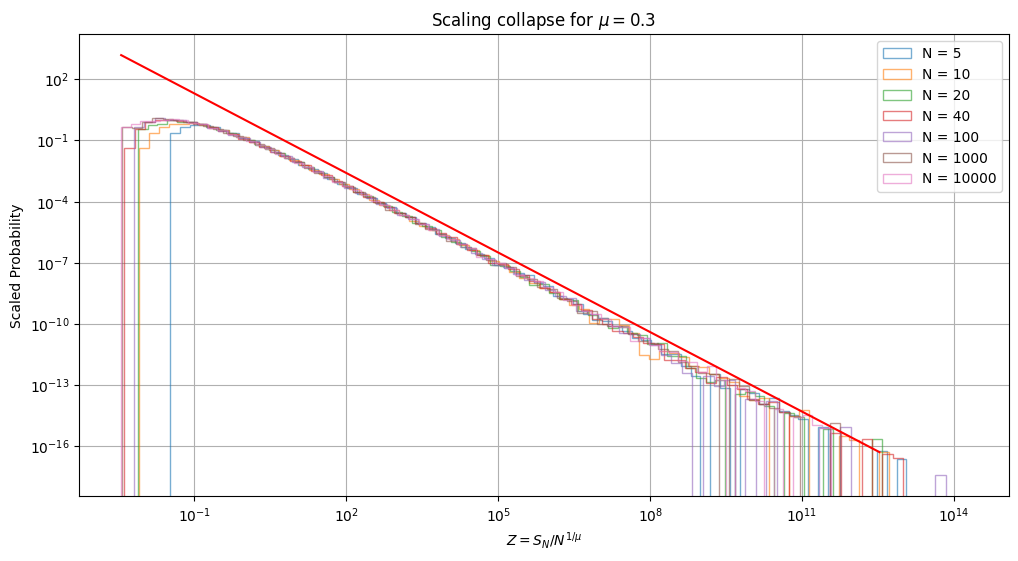

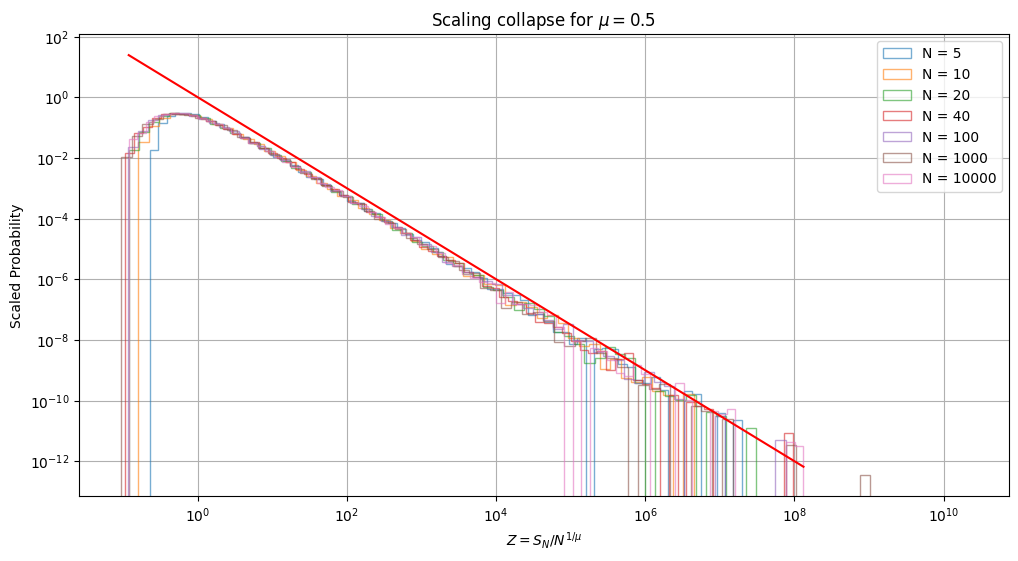

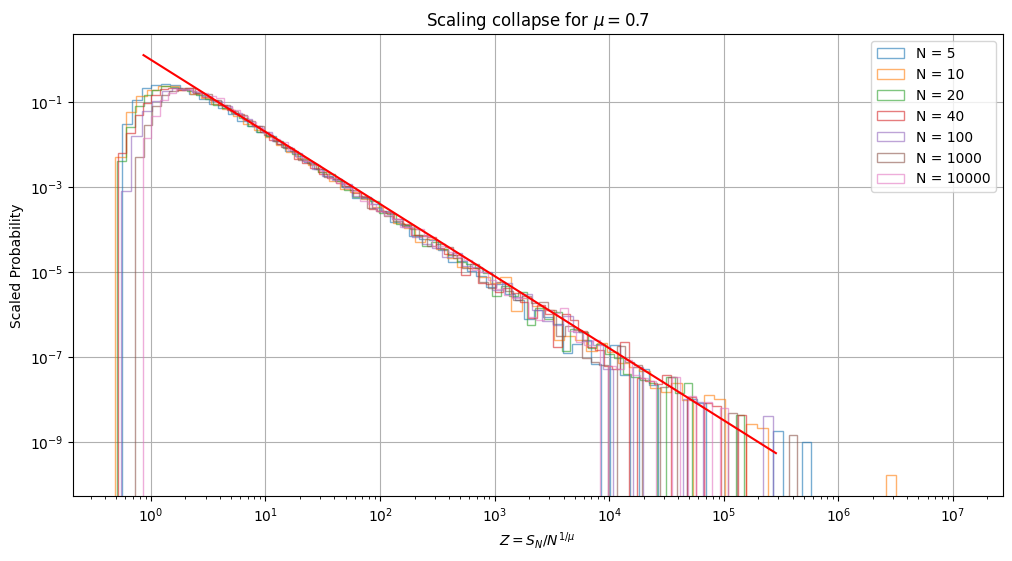

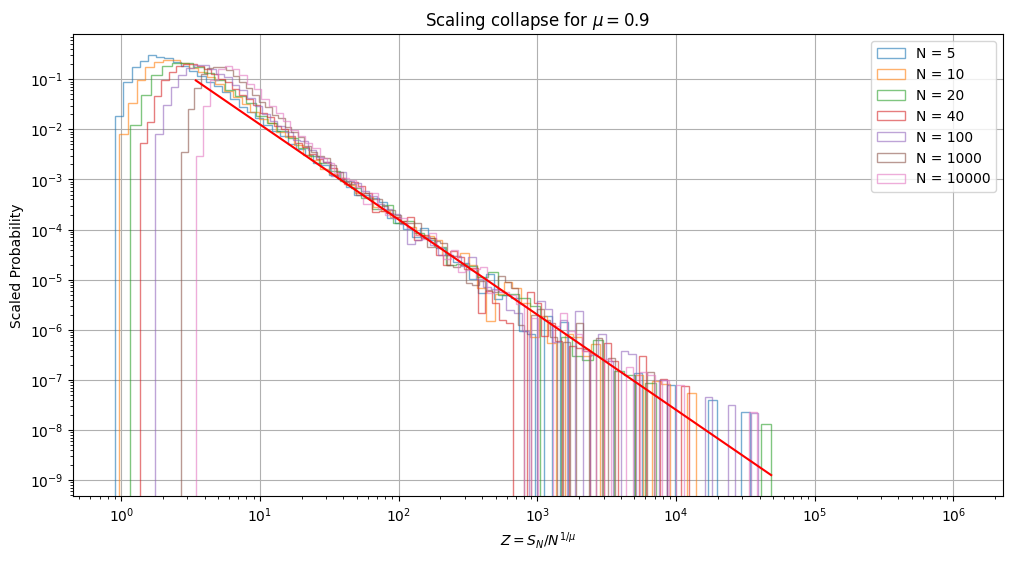

In [13]:
for mu in mu_values:
    plt.figure(figsize=(12, 6))
    
    for N in N_values:
        # Genera molte somme S_N per un dato N
        sums = []
        
        for _ in range(num_samples):
            xi = generate_fat_tailed(mu, N, x0)
            sums.append(np.sum(xi))
        
        # Riscalamento della distribuzione
        scaled_sums = np.array(sums) / N**(1 / mu)
        
        # Istogramma normalizzato delle somme scalate
        bins = np.logspace(math.log(min(scaled_sums),10),math.log(max(scaled_sums),10), 80)
        
        plt.hist(scaled_sums, bins=bins, density=True, alpha=0.6, label=f"N = {N}",histtype='step', stacked=True, fill=False)
    
    # Configurazione del grafico
    x = np.logspace(math.log(min(scaled_sums),10),math.log(max(scaled_sums),10), 100)
    plt.plot(x, Levi(x,mu), color='red')
    
    plt.title(f"Scaling collapse for $\\mu = {mu}$")
    plt.xlabel("$Z = S_N / N^{1 / \\mu}$")
    plt.ylabel("Scaled Probability")
    plt.xscale("log")
    plt.yscale("log")    
    plt.legend()
    plt.grid()
    plt.show()


# Here we study the relation between $x_{max}$ and $S_N$

From the graph below we se the asimptotic behaviour of the proportional constant between $x_{max}$ and $S_N$, this means that for sufficient large $N$, the sum is actually dominated/proportional by the maximum of the sum.

The proportional factor is approximately:<br>
for $\mu=0.1$ we have $ \approx 0.9$<br>
for $\mu=0.4$ we have $ \approx 0.7$<br>
for $\mu=0.7$ we have $ \approx 0.5$<br>
for $\mu=1.0$ we have $ \approx 0.35$<br>
for $\mu=1.3$ we have $ \approx 0.21$<br>
for $\mu=1.6$ we have $ \approx 0.18$<br>
for $\mu=1.9$ we have $ \approx 0.16$

where the behaviour of the higest $\mu$ haven't reached the asimptote, then the aprroximation is more coarse.

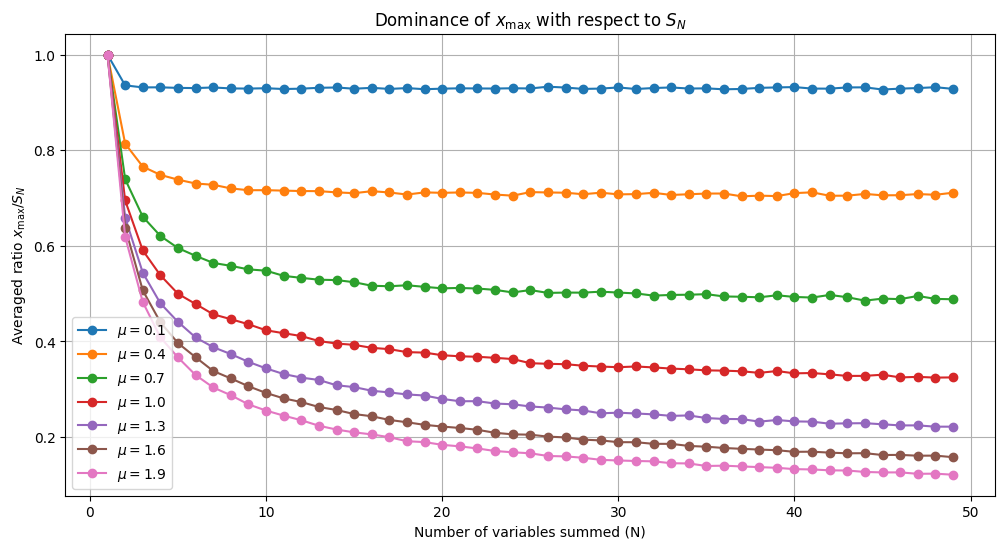

In [16]:
# Analisi di xmax rispetto a SN
mu_values_general = [0.1, 0.4, 0.7, 1.0, 1.3, 1.6, 1.9]  # Esempi per 0 < mu < 2
N_values_general = [*range(1,50)]

plt.figure(figsize=(12, 6))
for mu in mu_values_general:
    xmax_ratios = []
    for N in N_values_general:
        xmax_over_SN = []
        for _ in range(num_samples):
            xi = generate_fat_tailed(mu, N, x0)
            xmax = np.max(xi)
            SN = np.sum(xi)
            xmax_over_SN.append(xmax / SN)
        
        # Media del rapporto xmax / SN
        xmax_ratios.append(np.mean(xmax_over_SN))
    
    # Plot del rapporto medio xmax / SN
    plt.plot(N_values_general, xmax_ratios, 'o-', label=f"$\\mu = {mu}$")

plt.xlabel("Number of variables summed (N)")
plt.ylabel("Averaged ratio $x_{\\text{max}} / S_N$")
plt.title("Dominance of $x_{\\text{max}}$ with respect to $S_N$")
plt.legend()
plt.grid()
plt.show()
